# 03 Image Preprocessing


## Importing Libraries and Loading a Sample Image

We import the libraries and load one sample photo (a flower) as a PIL image. TorchVision `transforms` gives us ready-made preprocessing steps.

Image size (width, height): (640, 427)
Image mode: RGB


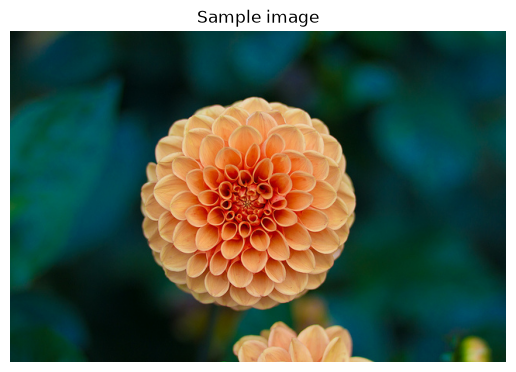

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.datasets import load_sample_images, load_digits
from sklearn.model_selection import train_test_split
import torch
import torchvision.transforms as T
flower = load_sample_images().images[1]
img = Image.fromarray(flower)
print("Image size (width, height):", img.size)
print("Image mode:", img.mode)
plt.imshow(img)
plt.title("Sample image")
plt.axis("off")
plt.show()

**Code Explanation:** `load_sample_images()` gives two photos and we take the second one (the flower). `Image.fromarray` turns the NumPy array into a PIL image. For PIL, the size is written as (width, height), so this photo is 640 pixels wide and 427 pixels high. The mode `RGB` means it has 3 colour channels.

## 1. Image Resizing

**Definition:** Resizing changes the width and height of an image to a fixed size.

**Example:** Photos from different cameras have different sizes. We resize all of them to 224 x 224 before giving them to the network.

**Why it is used?** A CNN with fully connected layers needs every image to have exactly the same size. Smaller images also make training faster and need less memory.

Original size      : (640, 427)
Resize((224, 224)) : (224, 224)
Resize(224)        : (335, 224)


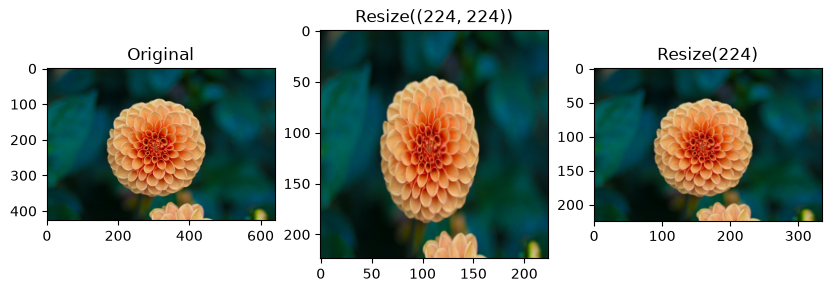

In [2]:
square = T.Resize((224, 224))(img)
keep_ratio = T.Resize(224)(img)
print("Original size      :", img.size)
print("Resize((224, 224)) :", square.size)
print("Resize(224)        :", keep_ratio.size)
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
ax[0].imshow(img)
ax[0].set_title("Original")
ax[1].imshow(square)
ax[1].set_title("Resize((224, 224))")
ax[2].imshow(keep_ratio)
ax[2].set_title("Resize(224)")
plt.show()

**Code Explanation:** `Resize((224, 224))` forces the image to be exactly 224 x 224. Because the original photo is wider than it is high, the flower gets squeezed and looks stretched. `Resize(224)` with a single number makes the shorter side 224 and keeps the shape of the picture, so the width becomes 335. The sizes printed above show the difference. Squeezing the picture changes the shape of objects, so it is a choice that depends on the dataset.

## 2. Cropping

**Definition:** Cropping cuts out a part of the image. Center crop takes the middle part. Random crop takes a part from a random position.

**Example:** We resize a photo to 256 x 256 and then cut out a 224 x 224 piece from it.

**Why it is used?** It gives the same size to all images without squeezing them, and it removes unwanted borders. Random crops during training give the model many slightly different views of the same image.

Resized size    : (256, 256)
Center crop size: (224, 224)
Random crop size: (224, 224)


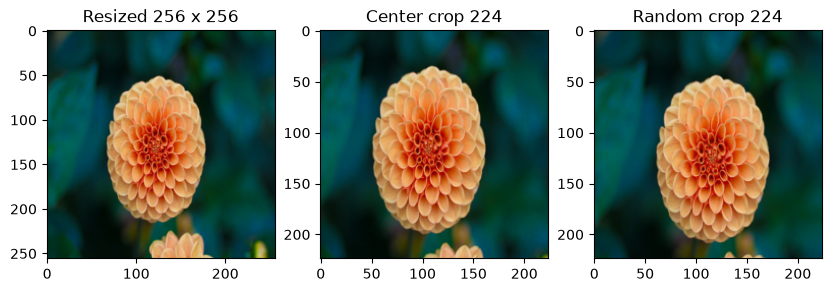

In [3]:
resized = T.Resize((256, 256))(img)
center = T.CenterCrop(224)(resized)
random_crop = T.RandomCrop(224)(resized)
print("Resized size    :", resized.size)
print("Center crop size:", center.size)
print("Random crop size:", random_crop.size)
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
ax[0].imshow(resized)
ax[0].set_title("Resized 256 x 256")
ax[1].imshow(center)
ax[1].set_title("Center crop 224")
ax[2].imshow(random_crop)
ax[2].set_title("Random crop 224")
plt.show()

**Code Explanation:** We first resize the photo to 256 x 256. `CenterCrop(224)` then cuts a 224 x 224 square from the middle, and `RandomCrop(224)` cuts a 224 x 224 square from a random place, so it can change every time you run it. Both crops are smaller than the resized image, because some border pixels are removed. A crop can also cut away a part of the object, so the crop size must be chosen carefully.

## 3. Normalization

**Definition:** Normalization scales the pixel values into a small fixed range, usually 0 to 1. For 8-bit images this is done by dividing every pixel by 255.

**Example:** A pixel value of 255 becomes 1.0, a pixel value of 0 stays 0.0 and a pixel value of 51 becomes 0.2.

**Why it is used?** Small numbers help the network learn faster and more stably than large numbers like 0 to 255.

In [4]:
pixels = np.array(img)
normalized = pixels / 255.0
print("Before -> smallest:", pixels.min(), "largest:", pixels.max())
print("After  -> smallest:", normalized.min(), "largest:", normalized.max())
print("Data type before:", pixels.dtype, "| after:", normalized.dtype)

Before -> smallest: 0 largest: 255
After  -> smallest: 0.0 largest: 1.0
Data type before: uint8 | after: float64


**Code Explanation:** `np.array(img)` gives the pixel values of the photo. Before normalization they go from 0 to 255 and the type is `uint8` (whole numbers). After dividing by 255.0 they go from 0.0 to 1.0 and the type is `float64` (decimal numbers). The picture itself looks the same. Only the scale of the numbers has changed.

## 4. Standardization

**Definition:** Standardization (also called z-score scaling) subtracts the mean and divides by the standard deviation, separately for each channel: `(pixel - mean) / std`. After that every channel has a mean of about 0 and a standard deviation of about 1.

**Example:** If the red channel has a mean of 0.5 and a standard deviation of 0.2, then a red value of 0.7 becomes (0.7 - 0.5) / 0.2 = 1.0.

**Why it is used?** It centers the data around 0, so that all channels have a similar range. This usually makes training faster and more stable. In `torchvision` it is done with `Normalize`, and the mean and std should be calculated from the training data.

In [5]:
tensor = T.ToTensor()(img)
mean = tensor.mean(dim=(1, 2))
std = tensor.std(dim=(1, 2))
print("Mean of each channel (R, G, B):", mean)
print("Std of each channel (R, G, B) :", std)
standardized = T.Normalize(mean, std)(tensor)
print("After standardization, mean:", standardized.mean(dim=(1, 2)))
print("After standardization, std :", standardized.std(dim=(1, 2)))

Mean of each channel (R, G, B): tensor([0.2162, 0.2885, 0.2235])
Std of each channel (R, G, B) : tensor([0.3491, 0.1785, 0.1303])
After standardization, mean: tensor([-4.2854e-09, -2.9509e-08,  2.1999e-08])
After standardization, std : tensor([1., 1., 1.])


**Code Explanation:** `ToTensor()` changes the image to a tensor with values between 0 and 1. We then calculate the mean and the standard deviation of each of the 3 channels (red, green, blue). `T.Normalize(mean, std)` applies `(pixel - mean) / std` to every channel. After that the mean of every channel is extremely close to 0 (tiny numbers like 1e-08 are practically zero) and the standard deviation is 1. In a real project we calculate the mean and std from all the training images, not from one picture, and then use the same numbers for validation and test images.

## 5. Channel Handling

**Definition:** Channel handling means making sure all images have the same number of channels, in the order the model expects. Images can be grayscale (1 channel), RGB (3 channels) or RGBA (4 channels, the last one is transparency).

**Example:** A dataset may contain a few grayscale photos and a few PNG files with transparency. They must be converted to RGB if the model was built for 3 channels.

**Why it is used?** A CNN has a fixed number of input channels. If one image has a different number of channels, the network gives an error.

In [6]:
gray = T.Grayscale(num_output_channels=1)(img)
gray3 = T.Grayscale(num_output_channels=3)(img)
rgba = img.convert("RGBA")
back_to_rgb = rgba.convert("RGB")
print("Original  :", img.mode, np.array(img).shape)
print("Grayscale :", gray.mode, np.array(gray).shape)
print("Gray as 3 channels:", gray3.mode, np.array(gray3).shape)
print("RGBA      :", rgba.mode, np.array(rgba).shape)
print("RGBA back to RGB:", back_to_rgb.mode, np.array(back_to_rgb).shape)

Original  : RGB (427, 640, 3)
Grayscale : L (427, 640)
Gray as 3 channels: RGB (427, 640, 3)
RGBA      : RGBA (427, 640, 4)
RGBA back to RGB: RGB (427, 640, 3)


**Code Explanation:** The original photo has 3 channels, shape (427, 640, 3). `Grayscale(num_output_channels=1)` gives 1 channel, shape (427, 640). `Grayscale(num_output_channels=3)` gives a grey picture that is copied into 3 channels, so a grayscale image can be fed to a model built for RGB. `convert("RGBA")` adds a 4th channel, and `convert("RGB")` removes it again. Another thing to watch is the channel order: PIL uses RGB, but OpenCV reads images as BGR, so the red and blue channels must be swapped if you mix the two.

## 6. Tensor Conversion

**Definition:** Tensor conversion changes an image into a PyTorch tensor. `ToTensor()` does three things together: it changes the type to float, divides the values by 255 so they lie between 0 and 1, and moves the channels to the front, changing (H, W, C) into (C, H, W).

**Example:** A photo of shape (427, 640, 3) with values 0 to 255 becomes a tensor of shape (3, 427, 640) with values 0 to 1.

**Why it is used?** PyTorch layers work only with tensors, and they expect the channels first.

In [7]:
pixels = np.array(img)
tensor = T.ToTensor()(img)
print("Before -> shape:", pixels.shape, "| type:", pixels.dtype)
print("After  -> shape:", tuple(tensor.shape), "| type:", tensor.dtype)
print("Value range after:", tensor.min().item(), "to", tensor.max().item())
batch = tensor.unsqueeze(0)
print("Batch shape (N, C, H, W):", tuple(batch.shape))

Before -> shape: (427, 640, 3) | type: uint8
After  -> shape: (3, 427, 640) | type: torch.float32
Value range after: 0.0 to 1.0
Batch shape (N, C, H, W): (1, 3, 427, 640)


**Code Explanation:** Before the conversion the image is a NumPy array of shape (427, 640, 3) with whole numbers. `ToTensor()` gives a tensor of shape (3, 427, 640) with decimal numbers between 0 and 1, so normalization and channel reordering are already included. A CNN expects a batch, so `unsqueeze(0)` adds the batch dimension and the final shape is (1, 3, 427, 640).

## 7. Image Augmentation

**Definition:** Augmentation creates new training images by randomly changing the existing ones, for example by flipping, rotating or changing the brightness.

**Example:** A photo of a flower flipped left to right is still a flower. We can turn 1000 photos into thousands of slightly different photos.

**Why it is used?** It gives the model more variety, which reduces overfitting and makes the model work better on new images. It is used only on the training images.

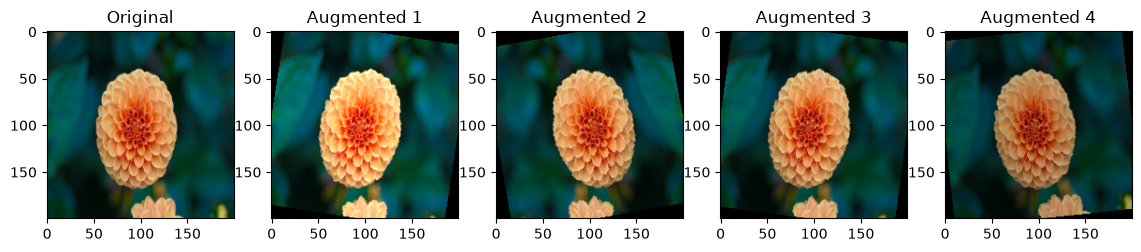

In [8]:
torch.manual_seed(1)
small = T.Resize((200, 200))(img)
augment = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(20),
    T.ColorJitter(brightness=0.4),
])
fig, ax = plt.subplots(1, 5, figsize=(14, 3))
ax[0].imshow(small)
ax[0].set_title("Original")
for i in range(1, 5):
    ax[i].imshow(augment(small))
    ax[i].set_title("Augmented " + str(i))
plt.show()

**Code Explanation:** `T.Compose` joins several steps into one pipeline. `RandomHorizontalFlip(p=0.5)` flips the image left to right half of the time, `RandomRotation(20)` rotates it by a random angle up to 20 degrees (the corners are filled with black), and `ColorJitter(brightness=0.4)` makes it randomly brighter or darker. We apply the same pipeline 4 times to the same image and get 4 different pictures. The model will see a slightly different version of the image every time.

## 8. Train / Validation / Test Preprocessing

**Definition:** The images are split into three parts. The training set is used to learn, the validation set is used to tune and compare models, and the test set is used only once at the end to measure the final result. Each part needs its own preprocessing rules.

**Example:** The training images get augmentation (random flips and rotations). The validation and test images get only the fixed steps (resize and normalize), so that their results are always the same and can be compared.

**Why it is used?** Random augmentation on the test images would give a different result every time. Also the mean and std for standardization must be calculated from the training set only. If we use the validation or test images for that, information leaks from them into the training, and the final result looks better than it really is (this is called data leakage).

In [9]:
digits = load_digits()
images = digits.images / 16.0
labels = digits.target
X_train, X_temp, y_train, y_temp = train_test_split(images, labels, test_size=0.3, random_state=0)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=0)
print("Train / Validation / Test sizes:", len(X_train), len(X_val), len(X_test))
train_mean = X_train.mean()
train_std = X_train.std()
print("Mean and std from the TRAIN set only:", round(train_mean, 3), round(train_std, 3))
X_train = (X_train - train_mean) / train_std
X_val = (X_val - train_mean) / train_std
X_test = (X_test - train_mean) / train_std
print("Train mean after:", round(X_train.mean(), 3))
print("Val mean after  :", round(X_val.mean(), 3))

Train / Validation / Test sizes: 1257 270 270
Mean and std from the TRAIN set only: 0.305 0.377
Train mean after: 0.0
Val mean after  : -0.001


**Code Explanation:** We split the 1797 digit images into 70 percent for training (1257), 15 percent for validation (270) and 15 percent for testing (270). The mean and std are calculated from the training images only. Then the same two numbers are used to standardize the training, validation and test images. The training mean after standardization is 0, while the validation mean is close to 0 but not exactly 0. This is normal: the validation images are new data, and we must not calculate separate numbers for them.

In [10]:
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])
test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])
train_a = train_transform(img)
train_b = train_transform(img)
test_a = test_transform(img)
test_b = test_transform(img)
print("Output shape:", tuple(test_a.shape))
print("Train transform gives the same result twice?", torch.equal(train_a, train_b))
print("Test transform gives the same result twice? ", torch.equal(test_a, test_b))

Output shape: (3, 224, 224)
Train transform gives the same result twice? False
Test transform gives the same result twice?  True


**Code Explanation:** The training transform has random steps (flip and rotation), and the test transform has only fixed steps. Both end with the same shape, (3, 224, 224), so the model accepts both. When we apply the training transform twice to the same image, the two results are different (`False`), because of the randomness. The test transform gives exactly the same result every time (`True`). The validation images use the same transform as the test images. The values 0.5 for the mean and std are simple example numbers that map values from 0 to 1 into -1 to 1.

## 9. Why Preprocessing Should Not Be Applied Blindly

**Definition:** Every dataset is different. A preprocessing step that helps for one dataset can hurt another. We must look at the images, understand the problem, and then choose the steps.

**Example:** Flipping a flower photo is harmless. Flipping a handwritten digit or a letter changes its meaning. Using the colour statistics of a photo dataset on a black and white digit dataset gives wrong values.

**Why it is used?** Blindly copying a preprocessing recipe from a tutorial can lower the accuracy without any error message. Always ask: does this step keep the meaning of the image for my problem?

### Case 1: Flipping can change the meaning

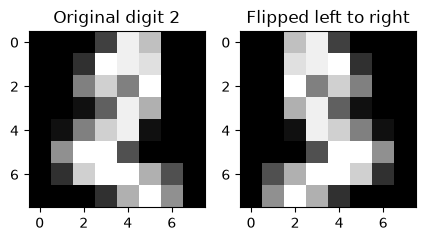

In [11]:
digit = digits.images[2]
flipped = np.fliplr(digit)
fig, ax = plt.subplots(1, 2, figsize=(5, 3))
ax[0].imshow(digit, cmap="gray")
ax[0].set_title("Original digit " + str(digits.target[2]))
ax[1].imshow(flipped, cmap="gray")
ax[1].set_title("Flipped left to right")
plt.show()

**Code Explanation:** `np.fliplr` flips the picture left to right. The original is the digit 2. The flipped picture is a mirrored 2, which is not a valid digit. If we used horizontal flip augmentation on a digit dataset, the model would be trained on wrong shapes. For the flower photo the same flip is safe, because a mirrored flower is still a flower. For other data the rule changes again: vertical flips are fine for satellite or microscope images, but not for street scenes.

### Case 2: Mean and std are different for every dataset

In [12]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]
print("ImageNet mean (R, G, B):", imagenet_mean)
print("ImageNet std  (R, G, B):", imagenet_std)
print("Digits mean (1 channel):", round((digits.images / 16.0).mean(), 3))
print("Digits std  (1 channel):", round((digits.images / 16.0).std(), 3))

ImageNet mean (R, G, B): [0.485, 0.456, 0.406]
ImageNet std  (R, G, B): [0.229, 0.224, 0.225]
Digits mean (1 channel): 0.305
Digits std  (1 channel): 0.376


**Code Explanation:** The numbers 0.485, 0.456, 0.406 (mean) and 0.229, 0.224, 0.225 (std) are the colour statistics of the ImageNet photo dataset, and many tutorials copy them. Our digits dataset is a single-channel black and white dataset, and its mean and std are different. Using the ImageNet numbers on it would shift and scale the pixels in the wrong way. The right approach is to calculate the mean and std from your own training set. The ImageNet numbers make sense mainly when you use a model that was pretrained on ImageNet.

### Case 3: Grayscale can remove useful information

In [14]:
two_pixels = np.array([[[150, 0, 0], [0, 76, 0]]], dtype=np.uint8)
two_gray = np.array(Image.fromarray(two_pixels).convert("L"))
print("Pixel colours (R, G, B):")
print(two_pixels[0])
print("After grayscale conversion:", two_gray)

Pixel colours (R, G, B):
[[150   0   0]
 [  0  76   0]]
After grayscale conversion: [[45 45]]


**Code Explanation:** We make an image with just 2 pixels: a dark red one and a dark green one. They are clearly different colours. After the conversion to grayscale both pixels get the same value, 45, so the model cannot tell them apart any more. For digits, colour does not matter, and grayscale is a good choice. But for tasks like telling ripe red fruit from unripe green fruit, or reading traffic lights, grayscale would throw away the most important information. The same thinking applies to `ColorJitter`, which is risky when the colour itself is the signal.